# TASK_1

## Importing necessary libraries

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#skip the first 4 lines and try again
df = pd.read_csv("worldpopulationdata.csv",skiprows=4)

## Clean column names to avoid "KeyError"

In [12]:
df.columns = df.columns.str.strip()

## Filter for 'Total Population' indicator

In [13]:
# We use 'Indicator Code' because that is the name in your CSV file
total_population_data = df[df['Indicator Code'] == 'SP.POP.TOTL'].copy()

## Convert population data for 2022 to numeric values

In [14]:
total_population_data['2022'] = pd.to_numeric(total_population_data['2022'], errors='coerce')

## Filter out regional groups

In [15]:
aggregates = ['WLD', 'HIC', 'MIC', 'LMY', 'IBT', 'UMC', 'IBD', 'EAS', 'EAP', 
              'LMC', 'LTE', 'SAS', 'TSA', 'IDA', 'TEA', 'EAR', 'SSF', 'TSS', 
              'OED', 'LDC', 'PST', 'FCS', 'ECS', 'AFE']
countries_only = total_population_data[~total_population_data['Country Code'].isin(aggregates)]

## Sort and extract the top 10 countries

In [16]:
top_10_countries = countries_only.sort_values(by="2022", ascending=False).head(10)

## Print the table

In [17]:
print("Top ten countries of total population (2022)\n")
print(top_10_countries[['Country Code', '2022']])

Top ten countries of total population (2022)

    Country Code          2022
109          IND  1.425423e+09
40           CHN  1.412175e+09
107          IDX  1.214632e+09
215          SSA  1.103704e+09
191          PRE  1.051202e+09
98           HPC  8.939063e+08
153          MEA  7.823494e+08
161          MNA  7.165087e+08
238          TMN  7.114650e+08
134          LCN  6.531081e+08


## Create the visualization

C:\Users\aashi\AppData\Local\Temp\ipykernel_16456\2110947851.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country Code', y='2022', data=top_10_countries, palette='viridis')


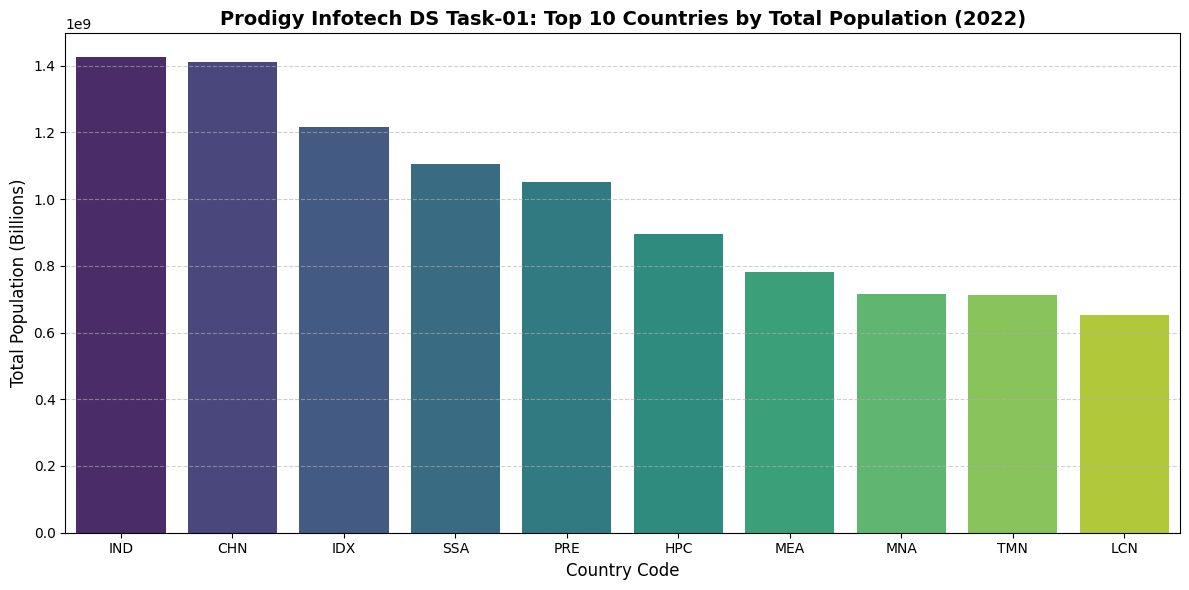

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Country Code', y='2022', data=top_10_countries, palette='viridis')

# Adding professional labels and title
plt.title('Prodigy Infotech DS Task-01: Top 10 Countries by Total Population (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Country Code', fontsize=12)
plt.ylabel('Total Population (Billions)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Final step: Show the plot
plt.tight_layout()
plt.show()